# Who Funds UK Political Parties? Analysis notebook

Charts and checks behind the README. Reads the clean data from `python/01_clean.py`. Run `./run_all.sh` first.

**Scope:** private donations accepted by registered political parties, Jan 2001 – Sep 2019, unless a chart says otherwise.
Public money (e.g. House of Commons "Short Money") and returned donations are excluded.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd

CHARTS = Path("../outputs/charts")
CHARTS.mkdir(parents=True, exist_ok=True)

# One default color; orange = "focus here"; red = "problem"; aqua and grey as extra categories.
BLUE, ORANGE, AQUA, RED, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#d03b3b", "#b4b2a9"
INK, INK_2, MUTED = "#0b0b0b", "#52514e", "#898781"

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.family": "sans-serif", "font.size": 10,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "figure.facecolor": "white", "axes.facecolor": "white",
})

def gbp(x, pos=None):
    return f"£{x/1e6:,.0f}M" if abs(x) >= 1e6 else f"£{x:,.0f}"

def clean_bars(ax, axis="y"):
    (ax.set_yticks if axis == "y" else ax.set_xticks)([])
    ax.spines["left" if axis == "y" else "bottom"].set_visible(False)

def footnote(ax, text, y=-0.12):
    ax.text(0, y, text, transform=ax.transAxes, color=MUTED, fontsize=8)

d = pd.read_csv("../data/clean/donations_clean.csv", low_memory=False, parse_dates=["donation_date"])
private = d[(d.recipient_type == "Political Party") & (d.is_public_funds == 0) & (d.is_returned == 0)].copy()
print(f"{len(d):,} records, £{d.value_gbp.sum()/1e6:,.0f}M | private party donations: {len(private):,}, £{private.value_gbp.sum()/1e6:,.0f}M")

65,278 records, £1,092M | private party donations: 55,064, £797M


## 1. The date bug hiding in the source file

Dates in the file are `dd/mm/yyyy` text. Excel converted every date with a day of 12 or less into a real date, **reading it as mm/dd**.
That hit about a third of all rows. The test below shows what happens to reporting delays with and without the fix.

In [2]:
raw = pd.read_excel("../data/raw/donations_raw.xlsx", usecols=["AcceptedDate", "ReceivedDate", "ReportedDate"])

def naive(x):
    if isinstance(x, str):
        return pd.to_datetime(x, format="%d/%m/%Y")
    return pd.NaT if pd.isna(x) else pd.Timestamp(x)

naive_lag = (raw.ReportedDate.map(naive) - raw.AcceptedDate.map(naive).fillna(raw.ReceivedDate.map(naive))).dt.days
compare = pd.DataFrame({
    "Without fix": [(naive_lag < 0).sum(), (naive_lag > 365).sum()],
    "With fix": [(d.report_lag_days < 0).sum(), (d.report_lag_days > 365).sum()],
}, index=["Reported before donated (impossible)", "Reported over a year late"])
compare

,Without fix,With fix
Reported before donated (impossible),9800,444
Reported over a year late,1336,422


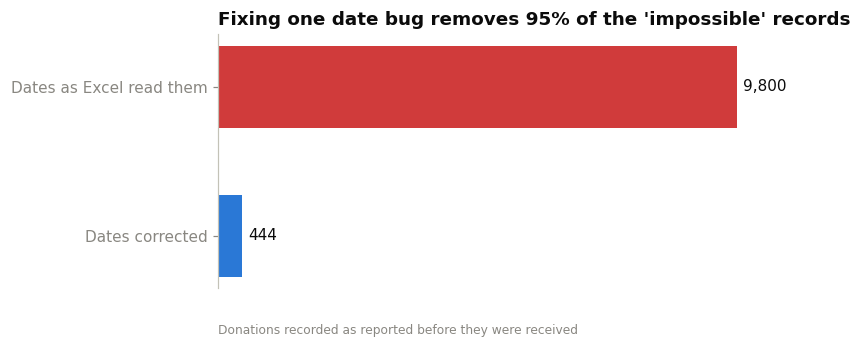

In [3]:
fig, ax = plt.subplots(figsize=(7, 3))
vals = [compare.loc["Reported before donated (impossible)", "Without fix"], compare.loc["Reported before donated (impossible)", "With fix"]]
bars = ax.barh(["Dates as Excel read them", "Dates corrected"], vals, color=[RED, BLUE], height=0.55)
ax.bar_label(bars, [f"{v:,}" for v in vals], padding=4, color=INK)
ax.invert_yaxis()
clean_bars(ax, "x")
ax.set_xlim(0, max(vals) * 1.15)
ax.set_title("Fixing one date bug removes 95% of the 'impossible' records")
footnote(ax, "Donations recorded as reported before they were received", y=-0.18)
fig.savefig(CHARTS / "01_date_bug.png")
plt.show()

## 2. Where the £1.09 billion actually goes

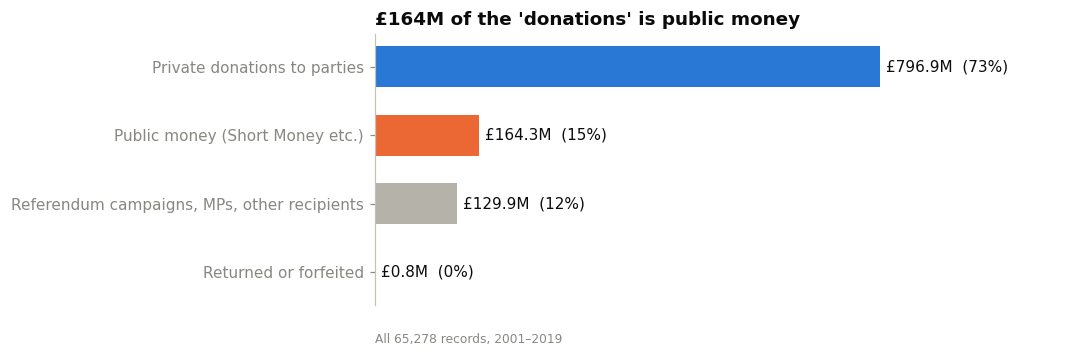

In [4]:
flow = pd.Series({
    "Private donations to parties": private.value_gbp.sum(),
    "Public money (Short Money etc.)": d.loc[d.is_public_funds == 1, "value_gbp"].sum(),
    "Referendum campaigns, MPs, other recipients": d.loc[(d.recipient_type != "Political Party") & (d.is_public_funds == 0) & (d.is_returned == 0), "value_gbp"].sum(),
    "Returned or forfeited": d.loc[d.is_returned == 1, "value_gbp"].sum(),
})
fig, ax = plt.subplots(figsize=(8, 3.2))
bars = ax.barh(flow.index, flow.values, color=[BLUE, ORANGE, GREY, GREY], height=0.6)
ax.bar_label(bars, [f"£{v/1e6:,.1f}M  ({v/flow.sum():.0%})" for v in flow.values], padding=4, color=INK)
ax.invert_yaxis()
clean_bars(ax, "x")
ax.set_xlim(0, flow.max() * 1.35)
ax.set_title(f"£{flow.iloc[1]/1e6:,.0f}M of the 'donations' is public money")
footnote(ax, "All 65,278 records, 2001–2019", y=-0.14)
fig.savefig(CHARTS / "02_money_flow.png")
plt.show()

## 3. Each party's funding model

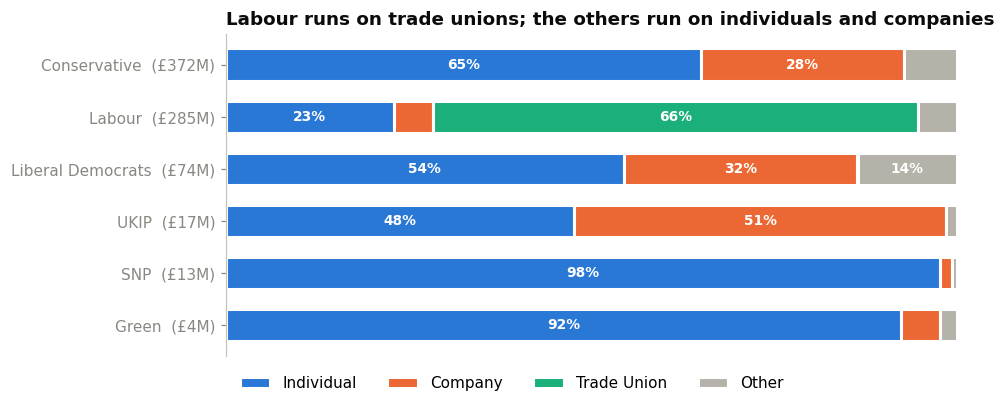

In [5]:
parties = ["Conservative", "Labour", "Liberal Democrats", "UKIP", "SNP", "Green"]
kind = private.donor_status.where(private.donor_status.isin(["Individual", "Company", "Trade Union"]), "Other")
mix = (private.assign(kind=kind).pivot_table(index="recipient_group", columns="kind", values="value_gbp", aggfunc="sum", fill_value=0)
       .loc[parties, ["Individual", "Company", "Trade Union", "Other"]])
mix_pct = mix.div(mix.sum(axis=1), axis=0)
totals = mix.sum(axis=1)

fig, ax = plt.subplots(figsize=(9, 3.8))
left = np.zeros(len(parties))
for col, color in zip(mix_pct.columns, [BLUE, ORANGE, AQUA, GREY]):
    ax.barh(mix_pct.index, mix_pct[col], left=left, color=color, height=0.62, label=col, edgecolor="white", linewidth=2)
    for i, v in enumerate(mix_pct[col]):
        if v >= 0.08:
            ax.text(left[i] + v / 2, i, f"{v:.0%}", ha="center", va="center", color="white", fontsize=9, fontweight="bold")
    left += mix_pct[col].values
ax.set_yticks(range(len(parties)), [f"{p}  (£{totals[p]/1e6:,.0f}M)" for p in parties])
ax.invert_yaxis()
clean_bars(ax, "x")
ax.legend(ncol=4, frameon=False, loc="upper left", bbox_to_anchor=(0, -0.02))
ax.set_title("Labour runs on trade unions; the others run on individuals and companies")
fig.savefig(CHARTS / "03_funding_mix.png")
plt.show()

## 4. Dependency risk: how much rides on a few donors?

**Top-10 share** = share of a party's private money from its 10 biggest donors. A high share means losing one or two donors would hurt.

In [6]:
rows = []
for p in parties:
    s = private[private.recipient_group == p].groupby("donor_key").value_gbp.sum().sort_values(ascending=False)
    share = s / s.sum()
    top_name = private.loc[private.donor_key == s.index[0], "donor_name"].iloc[0]
    rows.append({"party": p, "donors": len(s), "top_donor": top_name, "top1": share.iloc[0],
                 "top10": share.head(10).sum(), "hhi": round((share ** 2).sum() * 10000)})
conc = pd.DataFrame(rows).set_index("party").sort_values("top10")
conc

,donors,top_donor,top1,top10,hhi
party,,,,,
Conservative,7424,National Conservative Draws Society,0.024260,0.129927,34
Liberal Democrats,3741,THE JOSEPH ROWNTREE REFORM TRUST LIMITED,0.112457,0.289094,182
Green,231,Mrs Vivienne Westwood,0.078413,0.452398,287
UKIP,448,Highstone Group Ltd,0.126247,0.546177,403
Labour,2655,Unite the Union,0.139385,0.604906,575
SNP,185,Brian Souter,0.180058,0.723449,1055


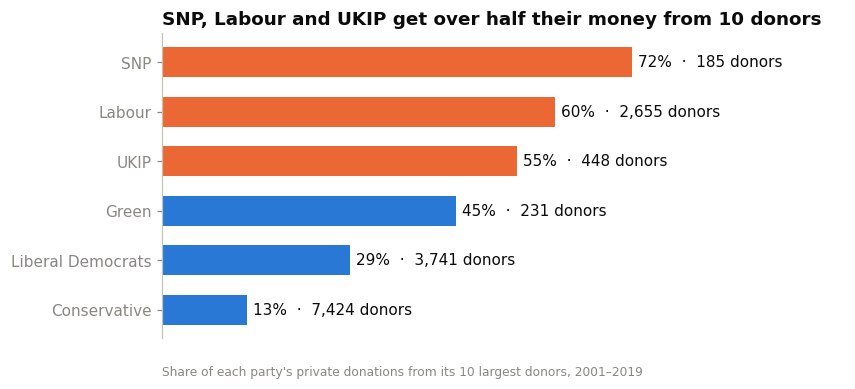

In [7]:
fig, ax = plt.subplots(figsize=(8, 3.6))
colors = [ORANGE if v >= 0.5 else BLUE for v in conc.top10]
bars = ax.barh(conc.index, conc.top10, color=colors, height=0.6)
ax.bar_label(bars, [f"{v:.0%}  ·  {n:,} donors" for v, n in zip(conc.top10, conc.donors)], padding=4, color=INK)
ax.set_xlim(0, 1.05)
clean_bars(ax, "x")
ax.set_title("SNP, Labour and UKIP get over half their money from 10 donors")
footnote(ax, "Share of each party's private donations from its 10 largest donors, 2001–2019", y=-0.12)
fig.savefig(CHARTS / "04_donor_concentration.png")
plt.show()

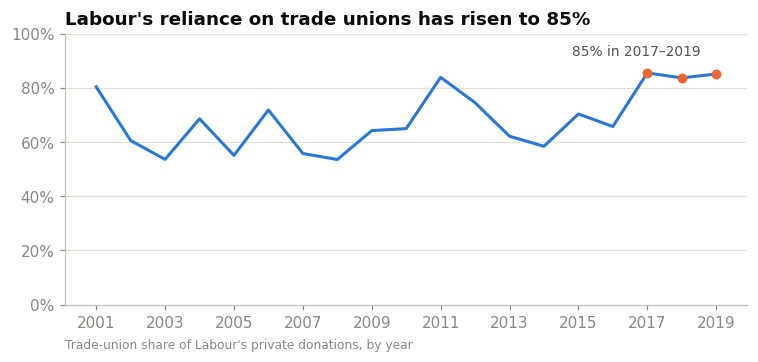

In [8]:
lab = private[private.recipient_group == "Labour"]
by_year = lab.pivot_table(index="year", columns=lab.donor_status.eq("Trade Union"), values="value_gbp", aggfunc="sum", fill_value=0)
union_share = by_year[True] / by_year.sum(axis=1)
union_share.index = union_share.index.astype(int)

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(union_share.index, union_share.values, color=BLUE, linewidth=2)
ax.scatter(union_share.index[-3:], union_share.values[-3:], color=ORANGE, zorder=3, s=30)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylim(0, 1)
ax.grid(axis="y", color="#e1e0d9", linewidth=0.8)
ax.set_xticks(range(2001, 2020, 2))
ax.annotate(f"{union_share.iloc[-1]:.0%} in 2017–2019", (union_share.index[-1], union_share.iloc[-1]),
            xytext=(-10, 12), textcoords="offset points", ha="right", color=INK_2, fontsize=9)
ax.set_title("Labour's reliance on trade unions has risen to 85%")
footnote(ax, "Trade-union share of Labour's private donations, by year", y=-0.16)
fig.savefig(CHARTS / "05_labour_union_share.png")
plt.show()

## 5. A few large gifts carry most of the money

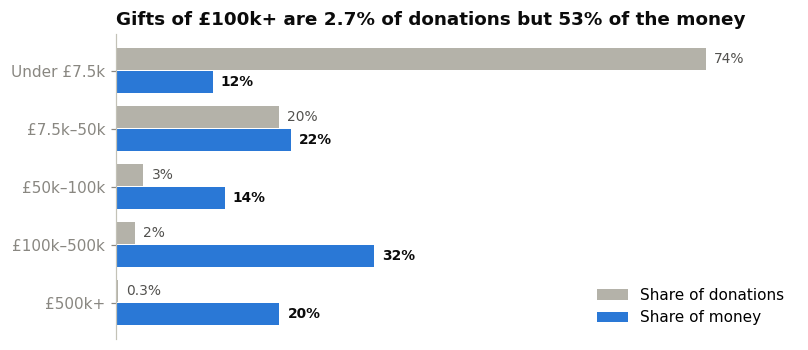

In [9]:
bands = pd.cut(private.value_gbp, [-1, 7499.99, 49999.99, 99999.99, 499999.99, 1e12],
               labels=["Under £7.5k", "£7.5k–50k", "£50k–100k", "£100k–500k", "£500k+"])
size = private.groupby(bands, observed=True).value_gbp.agg(count="size", value="sum")
size_pct = size / size.sum()

fig, ax = plt.subplots(figsize=(8, 3.6))
y = np.arange(len(size_pct))
ax.barh(y - 0.2, size_pct["count"], height=0.38, color=GREY, label="Share of donations")
ax.barh(y + 0.2, size_pct["value"], height=0.38, color=BLUE, label="Share of money")
for i, (c, v) in enumerate(zip(size_pct["count"], size_pct["value"])):
    ax.text(c + 0.01, i - 0.2, f"{c:.1%}" if c < 0.01 else f"{c:.0%}", va="center", color=INK_2, fontsize=9)
    ax.text(v + 0.01, i + 0.2, f"{v:.0%}", va="center", color=INK, fontsize=9, fontweight="bold")
ax.set_yticks(y, size_pct.index)
ax.invert_yaxis()
clean_bars(ax, "x")
ax.set_xlim(0, 0.85)
ax.legend(frameon=False, loc="lower right")
big = size_pct.loc[["£100k–500k", "£500k+"]].sum()
ax.set_title(f"Gifts of £100k+ are {big['count']:.1%} of donations but {big['value']:.0%} of the money")
fig.savefig(CHARTS / "06_gift_size.png")
plt.show()

## 6. Money follows elections

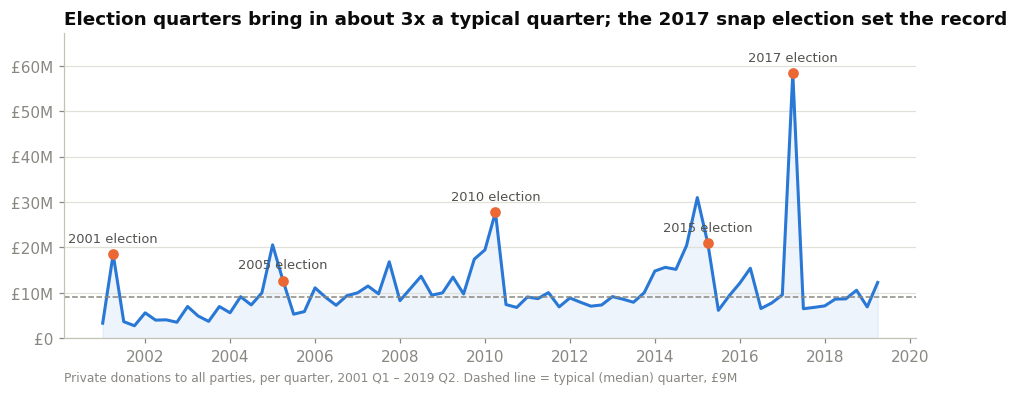

In [10]:
q = private.groupby(private.donation_date.dt.to_period("Q")).value_gbp.sum()
q = q[q.index < pd.Period("2019Q3")]  # the data ends on 2 Sep 2019, so 2019 Q3 is incomplete
q.index = q.index.to_timestamp()
elections = {"2001": "2001-04-01", "2005": "2005-04-01", "2010": "2010-04-01", "2015": "2015-04-01", "2017": "2017-04-01"}

fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(q.index, q.values, color=BLUE, linewidth=2)
ax.fill_between(q.index, q.values, color=BLUE, alpha=0.08)
for label, date in elections.items():
    t = pd.Timestamp(date)
    ax.scatter([t], [q.loc[t]], color=ORANGE, zorder=3, s=36)
    ax.annotate(f"{label} election", (t, q.loc[t]), xytext=(0, 8), textcoords="offset points", ha="center", fontsize=8.5, color=INK_2)
ax.axhline(q.median(), color=MUTED, linewidth=1, linestyle="--")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(gbp))
ax.set_ylim(0, q.max() * 1.15)
ax.grid(axis="y", color="#e1e0d9", linewidth=0.8)
ax.set_title("Election quarters bring in about 3x a typical quarter; the 2017 snap election set the record")
footnote(ax, f"Private donations to all parties, per quarter, 2001 Q1 – 2019 Q2. Dashed line = typical (median) quarter, £{q.median()/1e6:.0f}M", y=-0.14)
fig.savefig(CHARTS / "07_election_cycle.png")
plt.show()

## 7. Is the reporting system working?

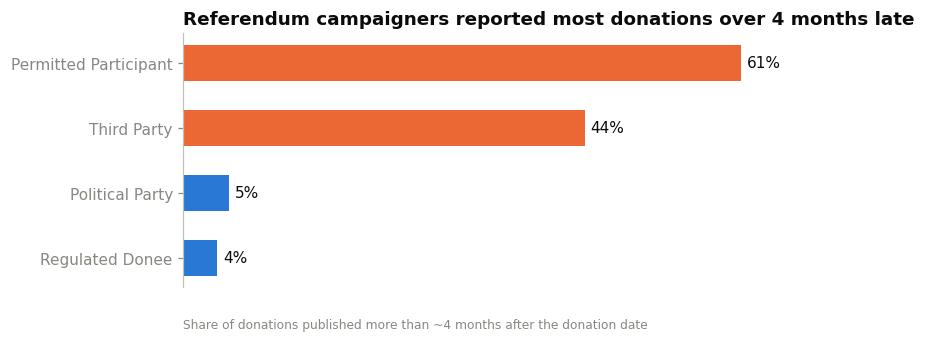

Impermissible or unidentified donations: 283, £849k, of which returned/forfeited: 283


In [11]:
ok = d[d.lag_status != "Date error"]
late = (ok.assign(late=ok.lag_status.isin(["4-12 months", "Over a year"]))
          .groupby("recipient_type").late.mean().sort_values())
fig, ax = plt.subplots(figsize=(8, 3.0))
bars = ax.barh(late.index, late.values, color=[ORANGE if v > 0.3 else BLUE for v in late.values], height=0.55)
ax.bar_label(bars, [f"{v:.0%}" for v in late.values], padding=4, color=INK)
ax.set_xlim(0, 0.75)
clean_bars(ax, "x")
ax.set_title("Referendum campaigners reported most donations over 4 months late")
footnote(ax, "Share of donations published more than ~4 months after the donation date", y=-0.16)
fig.savefig(CHARTS / "08_reporting_delay.png")
plt.show()

imp = d[d.donation_type.isin(["Impermissible Donor", "Unidentified Donor"])]
print(f"Impermissible or unidentified donations: {len(imp)}, £{imp.value_gbp.sum()/1e3:,.0f}k, of which returned/forfeited: {imp.is_returned.sum()}")

## 8. Summary

| Question | Answer |
|---|---|
| Can the raw file be trusted? | **Not as-is.** A third of dates were silently mangled by Excel; 942 donors are spelled several ways; £164M of "donations" is public money |
| How are parties funded? | Labour: 66% trade unions. Conservative: 65% individuals. SNP and Greens: over 90% individuals |
| Who carries dependency risk? | SNP (72% from top 10 donors), Labour (60%), UKIP (55%). Conservatives: 13% |
| Where is the money? | 2.7% of donations (£100k+) carry 53% of the value |
| When does it arrive? | Election quarters average ~3x a typical quarter |
| Is reporting working? | Parties: 95% reported within ~4 months. Referendum campaigners: 61% late. Every impermissible donation was returned |